# EV Battery Health Prediction Datasest 

Kaggel: https://www.kaggle.com/datasets/srisyra02/ev-battery-health-prediction-dataset-20k

This notebook performs exploratory data analysis (EDA) on the training dataset to evaluate missing data, feature distributions, and multicollinearity. The goal is to use these findings to inform preprocessing decisions, including imputation and feature handling.

    1. Load X_train and y_train
    2. Missingness analysis — amount/pattern of missing data
    3. Feature distributions — numerical and categorical features; skewness/outliers
    4. Determine potential imputation strategies
    5. Correlation analysis — correlation matrix/heatmap
    6. Investigate highly correlated feature pairs
    7. Document preprocessing decisions

## Import Libaries 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 1. Load X_train and y_train 

In [6]:
path = Path("../data/processed")

In [7]:
X_train = pd.read_csv(path / "X_train.csv")
y_train = pd.read_csv(path / "y_train.csv")

## 2. Missingness analysis — amount/pattern of missing data

In [17]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 68 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   vehicle_brand                    15493 non-null  str    
 1   vehicle_model                    15339 non-null  str    
 2   vehicle_type                     15471 non-null  str    
 3   manufacturing_year               15211 non-null  float64
 4   battery_manufacturer             15506 non-null  str    
 5   battery_chemistry                15430 non-null  str    
 6   battery_capacity_kwh             15445 non-null  float64
 7   drive_type                       15425 non-null  str    
 8   odometer_km                      15314 non-null  float64
 9   vehicle_age_years                15371 non-null  float64
 10  fleet_or_private                 15295 non-null  str    
 11  battery_serial                   16000 non-null  str    
 12  cycle_count                  

In [16]:
y_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   battery_failure  16000 non-null  int64
dtypes: int64(1)
memory usage: 125.1 KB


The target variable contains no missing values. Missingness in X_train is distributed across many features, with approximately 3–5% missing values per affected column. The predictor variables include both numerical (float) and string/categorical data types, indicating that preprocessing strategies will need to account for different feature types.

### Distribution of Numerical Features 

In [19]:
numeric_cols = X_train.select_dtypes(include=["number"]).columns
print(f"Number of numeric columns: {len(numeric_cols)}")
print(f"Numeric columns: {numeric_cols.tolist()}")

Number of numeric columns: 59
Numeric columns: ['manufacturing_year', 'battery_capacity_kwh', 'odometer_km', 'vehicle_age_years', 'cycle_count', 'battery_health_percent', 'state_of_charge', 'depth_of_discharge', 'state_of_health', 'cell_voltage_avg', 'cell_voltage_std', 'pack_voltage', 'cell_temperature_avg', 'cell_temperature_max', 'internal_resistance', 'charge_efficiency', 'discharge_efficiency', 'remaining_capacity', 'capacity_loss_percent', 'charging_cycles_last_month', 'fast_charge_ratio', 'slow_charge_ratio', 'average_charge_power_kw', 'average_charging_time', 'overnight_charging_ratio', 'home_charging_ratio', 'charging_interruptions', 'overcharge_events', 'average_speed', 'average_trip_distance', 'aggressive_acceleration_score', 'hard_braking_score', 'regenerative_braking_usage', 'highway_driving_ratio', 'city_driving_ratio', 'daily_distance', 'average_ambient_temperature', 'maximum_temperature', 'minimum_temperature', 'humidity', 'altitude', 'dust_exposure', 'last_service_days

Imputation is likely the most approatate apprach, depending on the distrubution and datatype. 

    - Approximately symmetric continuous variable → mean
    - Skewed continuous variable or variables with outliers → median
    - Categorical/string variable → mode or possibly "Unknown" if missingness itself has meaning
    - Integer variables → depends on what the integer represents. A count like sensor_fault_count may behave differently from a coded category like 1, 2, 3.

In [20]:
X_train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
manufacturing_year,15211.0,2019.495365,2.866667,2015.000,2017.0000,2020.0000,2022.0000,2024.000
battery_capacity_kwh,15445.0,86.914855,35.834112,25.000,55.7700,86.8700,118.1400,149.010
odometer_km,15314.0,169152.193196,74764.082358,500.000,115612.1750,157384.8000,211008.0750,450000.000
vehicle_age_years,15371.0,6.504101,2.884783,1.370,4.0000,6.5000,8.9900,11.550
cycle_count,15381.0,1356.550549,529.376246,209.000,983.0000,1289.0000,1652.0000,3369.000
battery_health_percent,15265.0,81.952802,9.006670,47.030,76.0100,83.0400,88.8600,99.800
state_of_charge,15222.0,51.047835,28.327412,2.000,26.3700,50.9900,75.6075,100.000
depth_of_discharge,15352.0,44.475692,17.036139,5.800,31.5000,43.8400,56.9500,90.320
state_of_health,15234.0,81.918445,9.119491,47.770,75.8325,82.9500,88.8700,100.000
cell_voltage_avg,15257.0,3.598300,0.126323,3.061,3.5140,3.6010,3.6860,3.850


Skewness ≈ 0 → approximately symmetric
Positive skewness → right-skewed (longer tail to the right)
Negative skewness → left-skewed (longer tail to the left)

In [24]:
skewness = X_train[numeric_cols].skew()
skewness

manufacturing_year                 0.001544
battery_capacity_kwh               0.000952
odometer_km                        0.866086
vehicle_age_years                  0.000997
cycle_count                        0.794161
battery_health_percent            -0.481543
state_of_charge                   -0.004598
depth_of_discharge                 0.132923
state_of_health                   -0.469384
cell_voltage_avg                  -0.178911
cell_voltage_std                   1.754216
pack_voltage                       0.051796
cell_temperature_avg               0.015667
cell_temperature_max               0.000902
internal_resistance                0.373350
charge_efficiency                 -0.292283
discharge_efficiency              -0.244080
remaining_capacity                 0.142307
capacity_loss_percent              0.475248
charging_cycles_last_month         0.014337
fast_charge_ratio                  0.473186
slow_charge_ratio                 -0.365552
average_charge_power_kw         

rough thresholds we've been working with:
- -0.5 to +0.5 → approximately symmetric
- +0.5 to +1 → moderately right-skewed
- > +1 → strongly right-skewed
- -1 to -0.5 → moderately left-skewed
- < -1 → strongly left-skewed

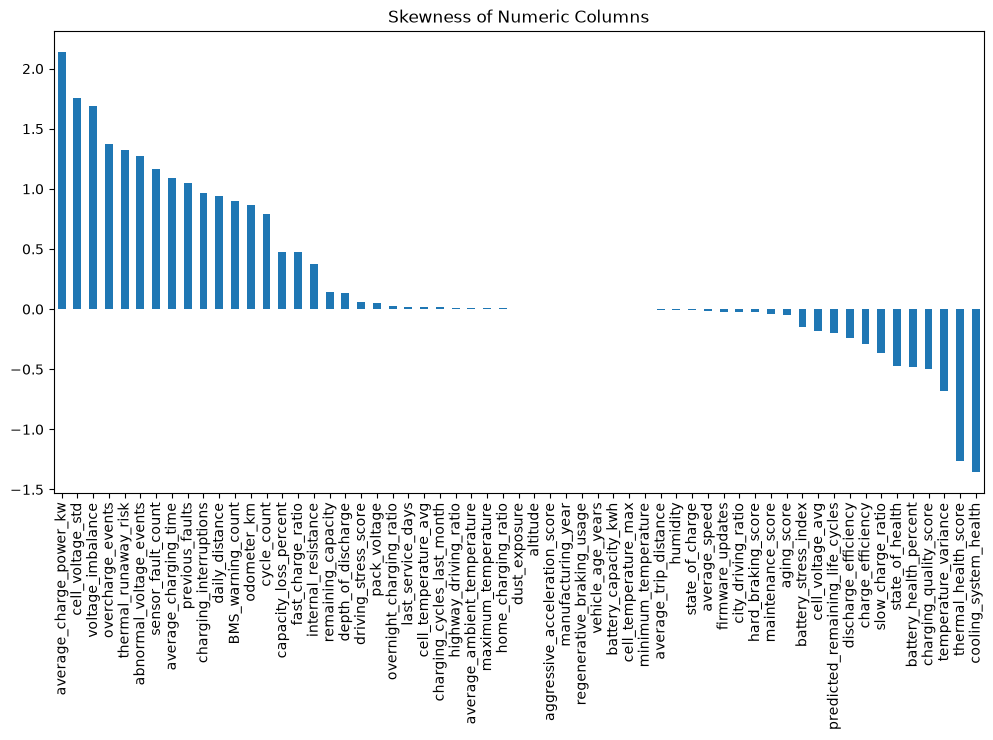

In [23]:
skewness.plot(kind="bar", figsize=(12, 6), title="Skewness of Numeric Columns")
plt.show()

In [25]:
potential_counts = [
    "cycle_count",
    "charging_cycles_last_month",
    "charging_interruptions",
    "overcharge_events",
    "firmware_updates",
    "previous_faults",
    "sensor_fault_count",
    "BMS_warning_count",
    "abnormal_voltage_events"
]

for col in potential_counts:
    print(f"\n{col}")
    print(X_train[col].value_counts().sort_index().head(20))


cycle_count
cycle_count
209.0    1
218.0    1
225.0    1
228.0    1
240.0    1
249.0    1
250.0    1
256.0    1
263.0    1
265.0    1
269.0    1
271.0    1
274.0    2
281.0    1
283.0    1
285.0    1
286.0    1
287.0    1
288.0    1
290.0    1
Name: count, dtype: int64

charging_cycles_last_month
charging_cycles_last_month
1.0     366
2.0     349
3.0     373
4.0     380
5.0     385
6.0     388
7.0     390
8.0     398
9.0     404
10.0    360
11.0    370
12.0    342
13.0    366
14.0    372
15.0    401
16.0    390
17.0    373
18.0    363
19.0    407
20.0    385
Name: count, dtype: int64

charging_interruptions
charging_interruptions
0.0    5569
1.0    5665
2.0    2763
3.0     958
4.0     215
5.0      45
6.0       5
Name: count, dtype: int64

overcharge_events
overcharge_events
0.0    9258
1.0    4814
2.0    1129
3.0     183
4.0      23
5.0       1
Name: count, dtype: int64

firmware_updates
firmware_updates
0.0     498
1.0     472
2.0     463
3.0     482
4.0     501
5.0     498
6.0     4